Задание
Создайте систему компьютерного зрения, которая будет определять тип геометрической :фигуры. Используя подготовленную базу и шаблон ноутбука проведите серию экспериментов по перебору гиперпараметров нейронной сети, распознающей три категории изображений (треугольник, круг, квадрат).

1. Поменяйте количество нейронов в сети, используя следующие значения:

- один слой 10 нейронов
- один слой 100 нейронов
- один слой 5000 нейронов.

2. Поменяйте активационную функцию в скрытых слоях с `relu` на `linear`.
3. Поменяйте размеры batch_size:
- 10
- 100
- 1000

4. Выведите на экран получившиеся точности.

Всего должно получиться 18 комбинаций указанных параметров.

### Создайте сравнительную таблицу по результатам проведенных тестов.

In [1]:
from tensorflow import keras
from keras.layers import Dense, Flatten
from keras.models import Sequential
from keras.optimizers import Adam
from keras import utils
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [2]:
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_light.zip', None, quiet=True)

'hw_light.zip'

In [3]:
!unzip -q hw_light.zip

In [4]:
# Путь к директории с базой
base_dir = '/content/hw_light'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                    target_size=(img_height, img_width),
                                                    color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        elif patch == '3':
            y_train.append(1)
        else:
            y_train.append(2)

# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (302, 20, 20, 1)
Размер массива y_train (302,)


In [25]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# если значения пикселей от 0 до 255 — нормализуем
x_train = x_train.astype("float32") / 255.0

# проверяем, какие классы в y_train
print("Классы:", np.unique(y_train))

model = Sequential()

# входной слой
model.add(Input(shape=(20, 20, 1)))

# преобразуем картинку 20x20 в один вектор
model.add(Flatten())

# скрытый слой
model.add(Dense(64, activation='relu'))

# ещё один скрытый слой, чтобы модель лучше обучалась
model.add(Dense(32, activation='relu'))

# выходной слой на 3 класса
# softmax превращает выходы в вероятности
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

loss, accuracy = model.evaluate(x_train, y_train)

results = []
results.append([64, "relu", 10, accuracy])

print("Итоговая loss:", loss)
print("Итоговая accuracy:", accuracy)

Классы: [0 1 2]
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5166 - loss: 1.0020
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6325 - loss: 0.7908
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7152 - loss: 0.7022
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7748 - loss: 0.6110
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8146 - loss: 0.5170
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8377 - loss: 0.4816
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8278 - loss: 0.4579
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8609 - loss: 0.4275
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8808 - loss: 0.3662
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8742 - loss: 0.3520
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9272 - loss: 0.2782  
Итоговая loss: 0.27822521328926086
Итоговая accuracy: 0.927152335643

In [6]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=10
model.fit(x_train, y_train, epochs=10, batch_size=100)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "relu", 100, accuracy])

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2616 - loss: 4.3183
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2682 - loss: 5.5585
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2914 - loss: 5.7540
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3146 - loss: 4.9010
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3576 - loss: 4.3016
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3642 - loss: 4.0294
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3609 - loss: 3.4212
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3576 - loss: 3.4165
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3742 - loss: 3.1164
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3742 - loss: 3.2101
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3742 - loss: 3.1589  


In [7]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
model.fit(x_train, y_train, epochs=10, batch_size=1000)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "relu", 1000, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step - accuracy: 0.3775 - loss: 6.2604
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3841 - loss: 5.9965
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3775 - loss: 5.9639
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3742 - loss: 5.9880
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3742 - loss: 5.9546
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3609 - loss: 5.9540
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3642 - loss: 5.9563
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3609 - loss: 5.9531
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3609 - loss: 5.8941
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3642 - loss: 5.9943
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3675 - loss: 6.1384  


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential() # Создание модели

# Входной слой
model.add(Input(shape=(20, 20, 1)))

# Преобразование изображения 20x20 в вектор
model.add(Flatten())

# Слой с 10 нейронами, функция активации linear
model.add(Dense(10, activation='linear'))

# Выходной слой на 3 класса
# softmax нужен, чтобы sparse_categorical_crossentropy нормально считал ошибку
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Обучение
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "linear", 10, accuracy])

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4205 - loss: 1.1378
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5927 - loss: 0.8913
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6987 - loss: 0.7776
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6987 - loss: 0.7457
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7053 - loss: 0.7236
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7219 - loss: 0.6919
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7682 - loss: 0.6474
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7781 - loss: 0.6402
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.6015
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7980 - loss: 0.5859
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7980 - loss: 0.5722  


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential() # Создание модели

# Входной слой
model.add(Input(shape=(20, 20, 1)))

# Преобразование изображения 20x20 в вектор
model.add(Flatten())

# Слой с 10 нейронами, функция активации linear
model.add(Dense(10, activation='linear'))

# Выходной слой на 3 класса
# softmax нужен для нормальной работы sparse_categorical_crossentropy
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100
)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "linear", 100, accuracy])

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3179 - loss: 1.7968 
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3179 - loss: 1.7720
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4040 - loss: 1.3978
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4801 - loss: 1.3613
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5033 - loss: 1.2240
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4834 - loss: 1.0913
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4834 - loss: 1.0701
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5166 - loss: 1.0277
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5596 - loss: 0.9953 
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5430 - loss: 1.0290
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5894 - loss: 0.8942  


In [10]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
model.fit(x_train, y_train, epochs=10, batch_size=1000)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "linear", 1000, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3444 - loss: 7.6852
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3444 - loss: 4.2760
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3013 - loss: 3.2828
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2748 - loss: 2.5548
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2583 - loss: 2.0087
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2517 - loss: 1.6588
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2318 - loss: 1.3492
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2583 - loss: 1.2474
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2649 - loss: 1.0932
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2815 - loss: 1.0932
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2947 - loss: 1.0932      


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential() # Создание модели

# Входной слой
model.add(Input(shape=(20, 20, 1)))

# Преобразование изображения 20x20 в вектор
model.add(Flatten())

# Добавление слоя со 100 нейронами, функция активации relu
model.add(Dense(100, activation='relu'))

# Выходной слой на 3 класса
# softmax нужен, чтобы loss нормально менялся
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "relu", 10, accuracy])

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5331 - loss: 0.9955
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7550 - loss: 0.6764
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.5902
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8278 - loss: 0.5239
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8444 - loss: 0.4609
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8576 - loss: 0.4141
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8709 - loss: 0.4036
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8775 - loss: 0.4079
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8974 - loss: 0.3152
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9172 - loss: 0.2798
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9305 - loss: 0.2559  


In [29]:
model = Sequential() # Создание модели

# Входной слой
model.add(Input(shape=(20, 20, 1)))

# Преобразование изображения 20x20 в вектор
model.add(Flatten())

# Добавление слоя со 100 нейронами, функция активации relu
model.add(Dense(100, activation='relu'))

# Выходной слой на 3 класса
# softmax нужен, чтобы функция потерь считалась нормально
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100
)

# Измерение точности и ошибки
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "relu", 100, loss, accuracy])

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2881 - loss: 1.2840
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4404 - loss: 1.1335
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5265 - loss: 0.9435
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5132 - loss: 0.9079
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7053 - loss: 0.7882
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6325 - loss: 0.8995
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7020 - loss: 0.7925
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6358 - loss: 0.7567
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5397 - loss: 0.9100
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5397 - loss: 0.8720
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7583 - loss: 0.6690  


In [13]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
model.fit(x_train, y_train, epochs=10, batch_size=1000)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "relu", 1000, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step - accuracy: 0.3576 - loss: 1.9081
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3245 - loss: 4.7769
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3311 - loss: 8.9216
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3212 - loss: 6.2757
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3278 - loss: 5.9124
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3543 - loss: 5.8742
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3907 - loss: 5.9782
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4007 - loss: 5.9782
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3775 - loss: 5.9782
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3609 - loss: 5.9782
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3543 - loss: 5.9782  


In [30]:
model = Sequential() # Создание модели

# Добавление слоя со 100 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, activation='linear'))

# Выходной слой на 3 класса
# softmax нужен, чтобы loss нормально считался
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

# Измерение ошибки и точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "linear", 10, loss, accuracy])

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5199 - loss: 1.0578
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6854 - loss: 0.7602
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6954 - loss: 0.7199
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6854 - loss: 0.7527
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7384 - loss: 0.6459
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8113 - loss: 0.5316
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8079 - loss: 0.5570
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7881 - loss: 0.5710
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8543 - loss: 0.4582
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8179 - loss: 0.4681
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7053 - loss: 0.6269  


In [15]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=100
model.fit(x_train, y_train, epochs=10, batch_size=100)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "linear", 100, accuracy])

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3742 - loss: 6.9265 
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3808 - loss: 7.7335
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4272 - loss: 2.9481
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3377 - loss: 1.0986
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3311 - loss: 1.0986
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3311 - loss: 1.0986
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3311 - loss: 1.0986
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3311 - loss: 1.0986
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3311 - loss: 1.0986
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3311 - loss: 1.0986 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3311 - loss: 1.0986      


In [16]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
model.fit(x_train, y_train, epochs=10, batch_size=1000)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "linear", 1000, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step - accuracy: 0.2384 - loss: 7.2572
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3013 - loss: 10.5486
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3278 - loss: 10.4765
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3278 - loss: 10.6221
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3311 - loss: 10.6148
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3311 - loss: 10.6111
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3311 - loss: 10.6572
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3311 - loss: 10.6572
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3311 - loss: 10.6083
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3278 - loss: 9.6872
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3046 - loss: 8.1786       


In [31]:
model = Sequential() # Создание модели

# Преобразование изображения 20x20 в вектор
model.add(Flatten(input_shape=(20, 20, 1)))

# Добавление слоя с 5000 нейронами, функция активации relu
model.add(Dense(5000, activation='relu'))

# Выходной слой на 3 класса
# softmax нужен, чтобы loss нормально считался
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

# Измерение ошибки и точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "relu", 10, loss, accuracy])

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4967 - loss: 1.7811
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6821 - loss: 0.7422
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7881 - loss: 0.5530
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7947 - loss: 0.5198
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8013 - loss: 0.5068
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8344 - loss: 0.4322
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8808 - loss: 0.3136
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8940 - loss: 0.2897
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8940 - loss: 0.2581
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9603 - loss: 0.1569
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9669 - loss: 0.1334


In [32]:
model = Sequential() # Создание модели

# Преобразование изображения 20x20 в вектор
model.add(Flatten(input_shape=(20, 20, 1)))

# Добавление слоя с 5000 нейронами, функция активации relu
model.add(Dense(5000, activation='relu'))

# Выходной слой на 3 класса
# softmax нужен, чтобы loss нормально считался
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100
)

# Измерение ошибки и точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "relu", 100, loss, accuracy])

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3742 - loss: 3.1084
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5132 - loss: 1.5203
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6093 - loss: 1.0573
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6821 - loss: 0.7637
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6589 - loss: 0.9181
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7185 - loss: 0.7542
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7185 - loss: 0.7319
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6689 - loss: 0.7376
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7152 - loss: 0.6894
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6325 - loss: 1.0055
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8013 - loss: 0.5670


In [19]:
model = Sequential() # Создание модели

# Добавление слоев с 5000 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(5000, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
model.fit(x_train, y_train, epochs=10, batch_size=1000)

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "relu", 1000, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step - accuracy: 0.3344 - loss: 7.2580
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.3278 - loss: 10.7045
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.3311 - loss: 10.7993
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.3311 - loss: 10.7947
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.3311 - loss: 10.7925
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.3311 - loss: 10.7925
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.3311 - loss: 10.7925
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.3311 - loss: 10.7901
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.3311 - loss: 10.7810
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.3311 - loss: 10.7810
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3311 - loss: 10.7810


In [33]:
model = Sequential() # Создание модели

# Преобразование изображения 20x20 в вектор
model.add(Flatten(input_shape=(20, 20, 1)))

# Добавление слоя с 5000 нейронами, функция активации linear
model.add(Dense(5000, activation='linear'))

# Выходной слой на 3 класса
# softmax нужен, чтобы loss нормально считался
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

# Измерение ошибки и точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "linear", 10, loss, accuracy])

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5166 - loss: 3.4327
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6854 - loss: 0.9285
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7417 - loss: 0.7946
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7417 - loss: 0.6611
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8046 - loss: 0.5597
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6987 - loss: 0.7768
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7517 - loss: 0.6053
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7682 - loss: 0.5968
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8510 - loss: 0.4385
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8344 - loss: 0.4570
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7748 - loss: 0.5754


In [34]:
model = Sequential() # Создание модели

# Преобразование изображения 20x20 в вектор
model.add(Flatten(input_shape=(20, 20, 1)))

# Добавление слоя с 5000 нейронами, функция активации linear
model.add(Dense(5000, activation='linear'))

# Выходной слой на 3 класса
# softmax нужен, чтобы loss нормально считался
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100
)

# Измерение ошибки и точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "linear", 100, loss, accuracy])

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3642 - loss: 10.3539
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4437 - loss: 4.2357
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4470 - loss: 3.7950
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6656 - loss: 1.7167
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6689 - loss: 1.2387
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6424 - loss: 1.5438
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6921 - loss: 1.0621
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6391 - loss: 1.4987
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6358 - loss: 1.4598
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5563 - loss: 1.6640
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6291 - loss: 1.7207


In [35]:
model = Sequential() # Создание модели

# Преобразование изображения 20x20 в вектор
model.add(Flatten(input_shape=(20, 20, 1)))

# Добавление слоя с 5000 нейронами, функция активации linear
model.add(Dense(5000, activation='linear'))

# Выходной слой на 3 класса
# softmax нужен, чтобы loss нормально считался
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Задание batch_size=1000
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1000
)

# Измерение ошибки и точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "linear", 1000, loss, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3411 - loss: 1.1761
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.3377 - loss: 12.8151
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.3311 - loss: 12.3588
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.3311 - loss: 5.8491
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6391 - loss: 1.3798
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.3311 - loss: 6.2751
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.3477 - loss: 5.6209
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.3377 - loss: 6.0300
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.3377 - loss: 5.5407
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5530 - loss: 2.8475
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5298 - loss: 2.3268


In [38]:
# Отдельная ячейка - Простое сохранение весов
from google.colab import files

# Сохраняем веса текущей модели (последней обученной)
model.save_weights('lite.weights.h5')
print("✓ Веса сохранены в lite.weights.h5")

✓ Веса сохранены в lite.weights.h5


In [40]:
# Вывод итоговой таблицы
import pandas as pd

df = pd.DataFrame(
    results,
    columns=["Нейроны", "Активация", "Размер пакета", "Ошибка", "Точность"]
)

display(df)

,Нейроны,Активация,Размер пакета,Ошибка,Точность
0,64,relu,10,0.927152,NaN
1,10,linear,10,0.798013,NaN
2,10,linear,100,0.589404,NaN
3,100,relu,10,0.930464,NaN
4,100,relu,100,0.669015,0.758278
5,100,linear,10,0.626892,0.705298
6,5000,relu,10,0.133434,0.966887
7,5000,relu,100,0.566968,0.801324
8,5000,linear,10,0.575440,0.774834
9,5000,linear,100,1.720727,0.629139



Модель: нейроны = 10, функция = relu, размер пакета = 10
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4232 - loss: 1.1173 - val_accuracy: 0.0000e+00 - val_loss: 1.6749
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6183 - loss: 0.8784 - val_accuracy: 0.0000e+00 - val_loss: 1.9666
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6515 - loss: 0.8458 - val_accuracy: 0.0000e+00 - val_loss: 1.8337
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6680 - loss: 0.7880 - val_accuracy: 0.0000e+00 - val_loss: 1.6982
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6805 - loss: 0.7452 - val_accuracy: 0.0000e+00 - val_loss: 1.6728
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6473 - loss: 0.7430 - val_accuracy: 0.0000e+00 - val_loss: 1.7325
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6722 - loss: 0.7012 - val_accuracy: 0.0000e+00 - val_loss: 1.6650
Epoch 8/10
25/25 ━━━━━━━━━━━━━━

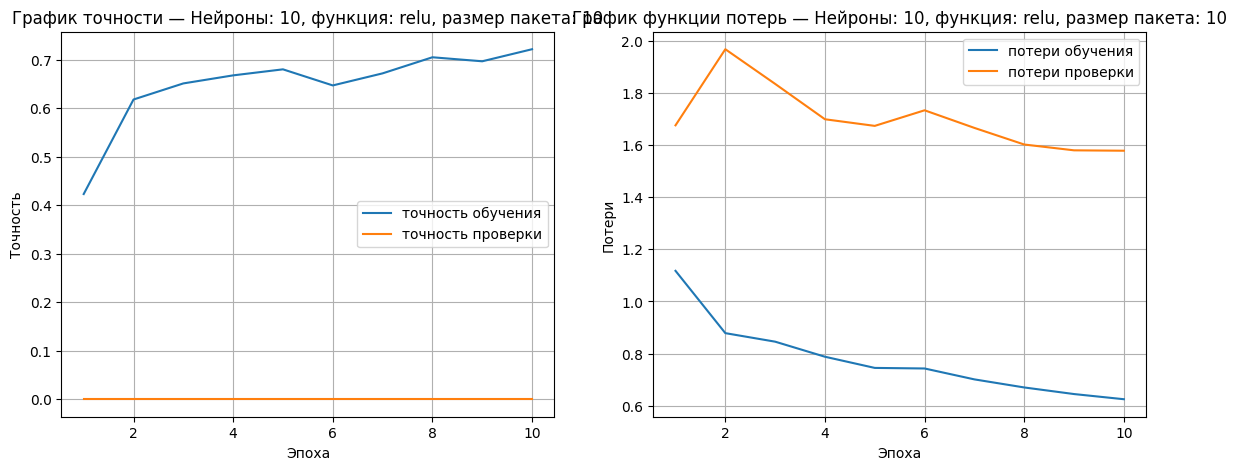


Модель: нейроны = 10, функция = relu, размер пакета = 100
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.4232 - loss: 1.3345 - val_accuracy: 0.0000e+00 - val_loss: 2.2543
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3485 - loss: 1.1934 - val_accuracy: 0.0328 - val_loss: 1.9528
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3942 - loss: 1.0836 - val_accuracy: 0.1311 - val_loss: 1.5774
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4855 - loss: 0.9840 - val_accuracy: 0.1148 - val_loss: 1.6287
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6349 - loss: 0.8988 - val_accuracy: 0.0492 - val_loss: 1.9239
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6598 - loss: 0.8618 - val_accuracy: 0.0328 - val_loss: 2.0041
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6805 - loss: 0.8274 - val_accuracy: 0.0656 - val_loss: 1.8605
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 

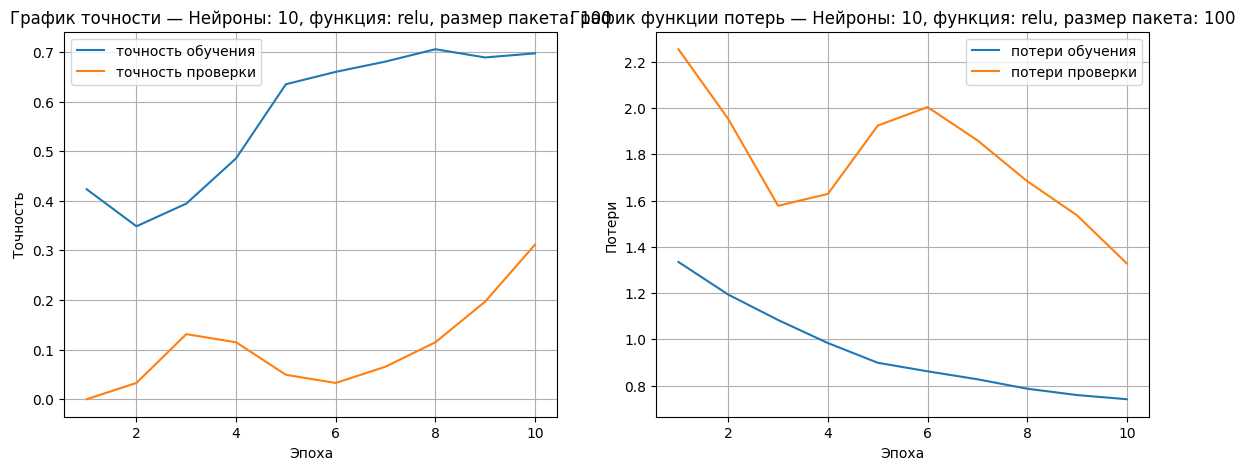


Модель: нейроны = 10, функция = relu, размер пакета = 1000
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1618 - loss: 2.8505 - val_accuracy: 0.9672 - val_loss: 0.2890
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.1577 - loss: 2.1973 - val_accuracy: 0.8852 - val_loss: 0.5091
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.1701 - loss: 1.7095 - val_accuracy: 0.8033 - val_loss: 0.7387
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.1992 - loss: 1.3953 - val_accuracy: 0.6393 - val_loss: 0.9236
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.2822 - loss: 1.2025 - val_accuracy: 0.3770 - val_loss: 1.0587
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.4357 - loss: 1.0900 - val_accuracy: 0.2295 - val_loss: 1.1596
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5602 - loss: 1.0276 - val_accuracy: 0.0984 - val_loss: 1.2261
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy:

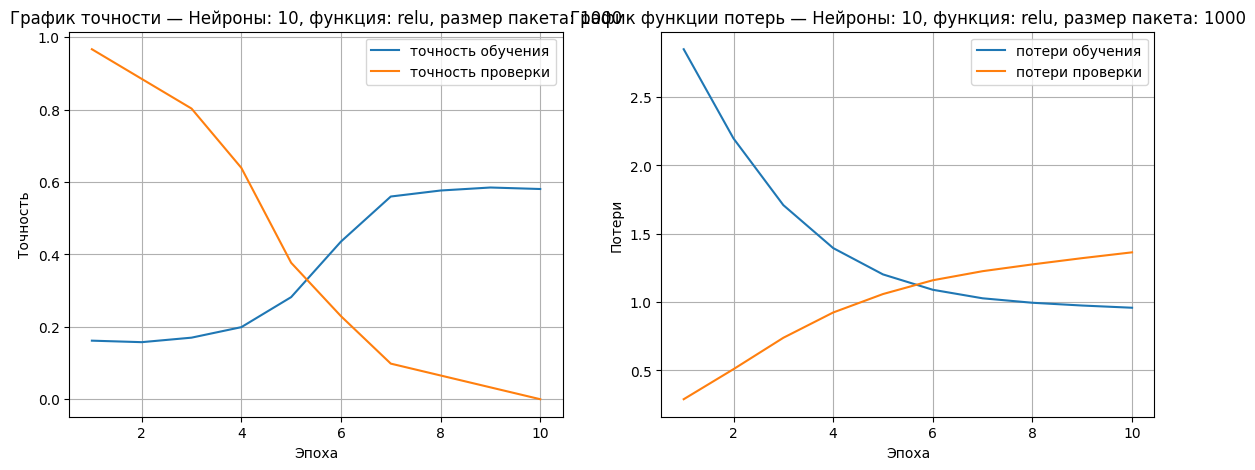


Модель: нейроны = 10, функция = linear, размер пакета = 10
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4481 - loss: 1.1171 - val_accuracy: 0.0492 - val_loss: 1.7738
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5809 - loss: 0.8705 - val_accuracy: 0.0492 - val_loss: 2.0658
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5934 - loss: 0.8322 - val_accuracy: 0.5082 - val_loss: 1.0731
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6805 - loss: 0.6970 - val_accuracy: 0.4098 - val_loss: 1.1683
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7012 - loss: 0.6569 - val_accuracy: 0.5574 - val_loss: 0.9688
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7220 - loss: 0.6294 - val_accuracy: 0.4262 - val_loss: 1.2603
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6888 - loss: 0.6505 - val_accuracy: 0.1475 - val_loss: 2.1384
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accur

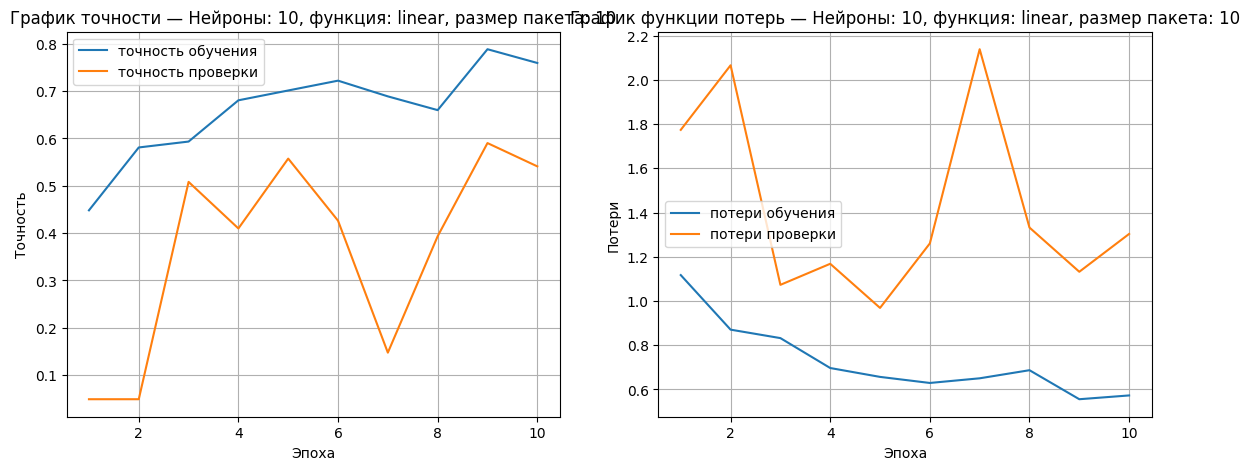


Модель: нейроны = 10, функция = linear, размер пакета = 100
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.4066 - loss: 1.1966 - val_accuracy: 0.1148 - val_loss: 1.4820
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4191 - loss: 1.0961 - val_accuracy: 0.0328 - val_loss: 1.8314
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5145 - loss: 1.0298 - val_accuracy: 0.0164 - val_loss: 1.8170
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5311 - loss: 0.9557 - val_accuracy: 0.2131 - val_loss: 1.3628
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5519 - loss: 0.9193 - val_accuracy: 0.2295 - val_loss: 1.3319
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5851 - loss: 0.8736 - val_accuracy: 0.1148 - val_loss: 1.5882
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6058 - loss: 0.8500 - val_accuracy: 0.1311 - val_loss: 1.5259
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.

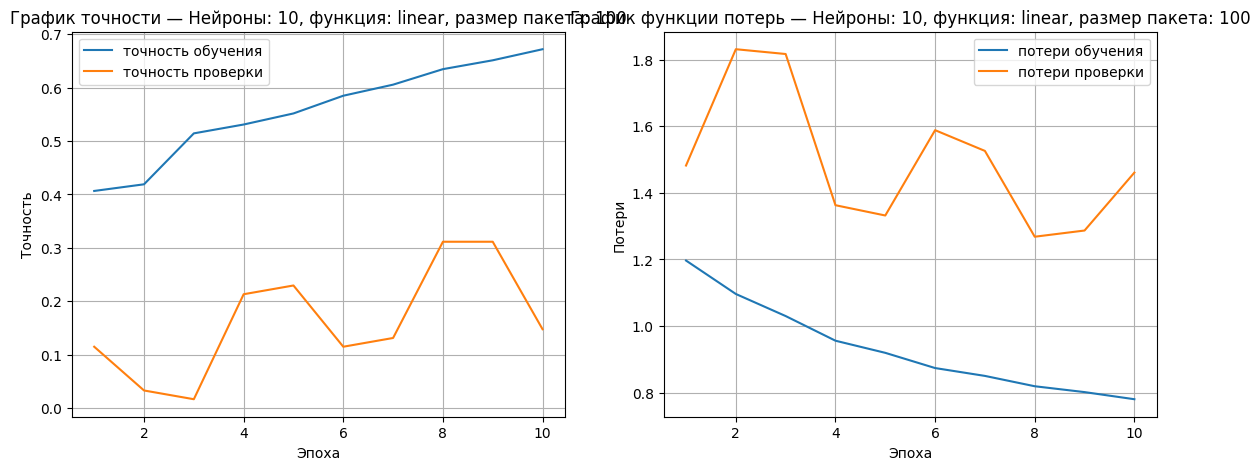


Модель: нейроны = 10, функция = linear, размер пакета = 1000
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4108 - loss: 1.9590 - val_accuracy: 0.1475 - val_loss: 1.7798
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3776 - loss: 1.4236 - val_accuracy: 0.1803 - val_loss: 1.6657
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3900 - loss: 1.2432 - val_accuracy: 0.1639 - val_loss: 1.9237
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4108 - loss: 1.2994 - val_accuracy: 0.1148 - val_loss: 2.1946
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4315 - loss: 1.3794 - val_accuracy: 0.0820 - val_loss: 2.3036
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.4315 - loss: 1.3729 - val_accuracy: 0.0820 - val_loss: 2.2623
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4398 - loss: 1.2894 - val_accuracy: 0.0820 - val_loss: 2.1330
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accurac

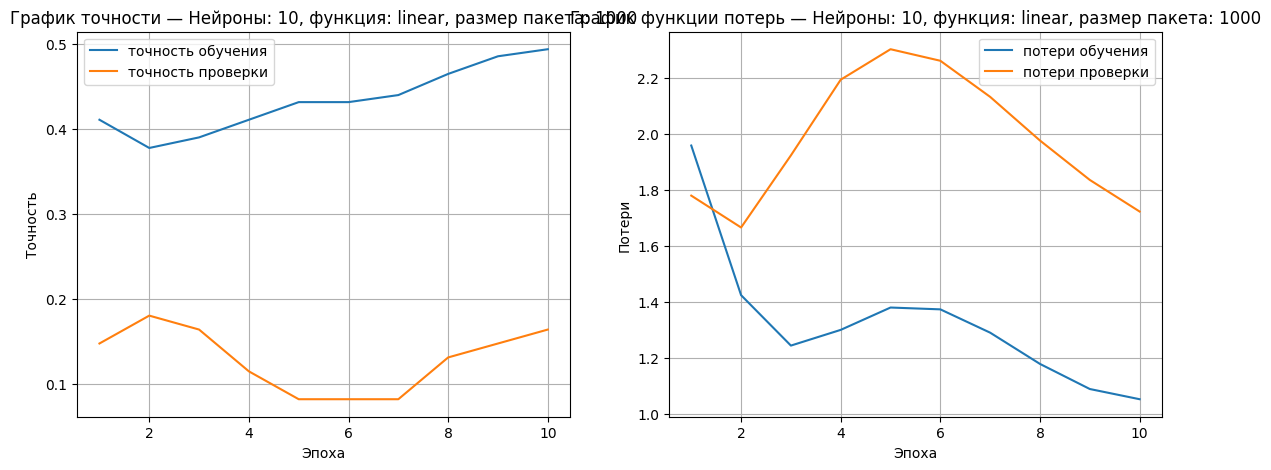


Модель: нейроны = 100, функция = relu, размер пакета = 10
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5685 - loss: 0.9257 - val_accuracy: 0.5574 - val_loss: 0.9600
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6929 - loss: 0.7028 - val_accuracy: 0.4754 - val_loss: 1.0045
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7386 - loss: 0.5597 - val_accuracy: 0.2623 - val_loss: 1.7195
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7967 - loss: 0.5116 - val_accuracy: 0.7869 - val_loss: 0.5680
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8008 - loss: 0.4708 - val_accuracy: 0.6230 - val_loss: 1.0193
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8174 - loss: 0.4501 - val_accuracy: 0.3770 - val_loss: 1.7560
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8506 - loss: 0.3936 - val_accuracy: 0.4754 - val_loss: 1.5150
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc

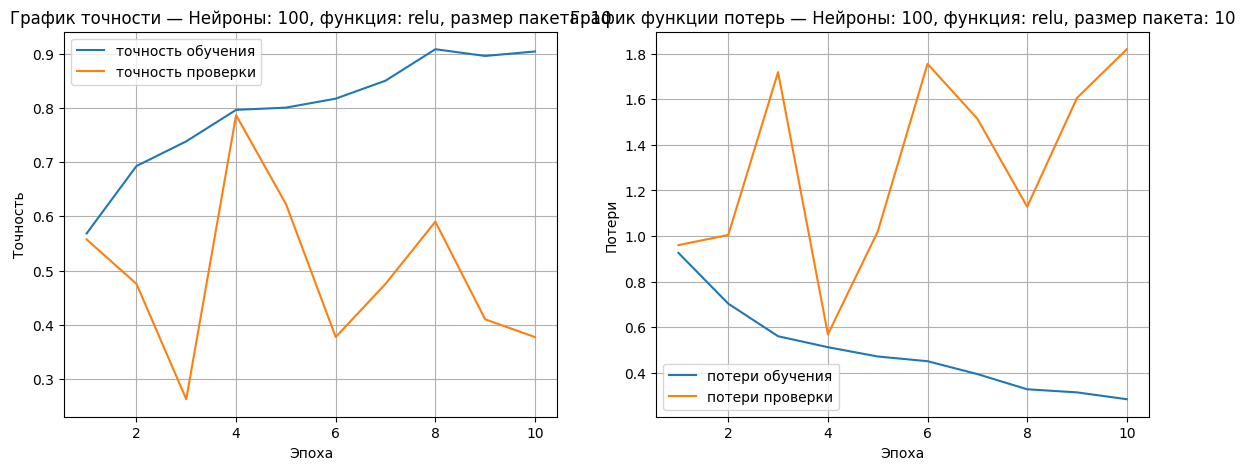


Модель: нейроны = 100, функция = relu, размер пакета = 100
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.4564 - loss: 1.0367 - val_accuracy: 0.0000e+00 - val_loss: 2.1357
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6515 - loss: 0.8079 - val_accuracy: 0.2623 - val_loss: 1.1524
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7261 - loss: 0.7401 - val_accuracy: 0.5246 - val_loss: 0.9334
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7386 - loss: 0.6715 - val_accuracy: 0.1639 - val_loss: 1.4380
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7261 - loss: 0.6294 - val_accuracy: 0.2787 - val_loss: 1.2594
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7635 - loss: 0.5814 - val_accuracy: 0.6230 - val_loss: 0.8832
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7842 - loss: 0.5503 - val_accuracy: 0.5410 - val_loss: 1.0212
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy:

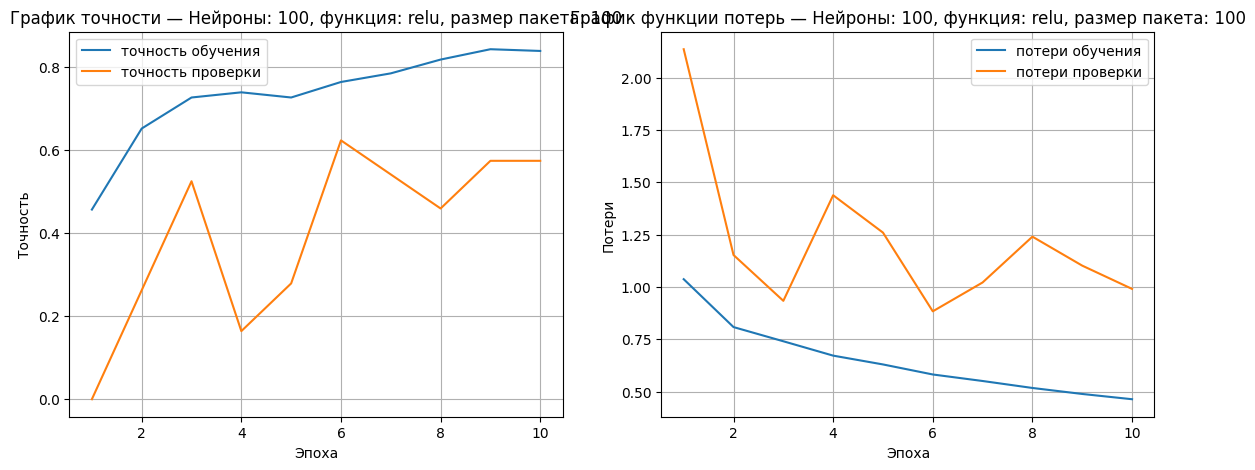


Модель: нейроны = 100, функция = relu, размер пакета = 1000
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2116 - loss: 1.2298 - val_accuracy: 0.0164 - val_loss: 2.2463
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.4813 - loss: 1.0291 - val_accuracy: 0.0000e+00 - val_loss: 2.7776
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6224 - loss: 0.9770 - val_accuracy: 0.0000e+00 - val_loss: 2.8644
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5934 - loss: 0.9547 - val_accuracy: 0.0000e+00 - val_loss: 2.6936
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.6100 - loss: 0.9017 - val_accuracy: 0.0000e+00 - val_loss: 2.3992
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6722 - loss: 0.8265 - val_accuracy: 0.0164 - val_loss: 2.0271
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6680 - loss: 0.7680 - val_accuracy: 0.1475 - val_loss: 1.5952
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms

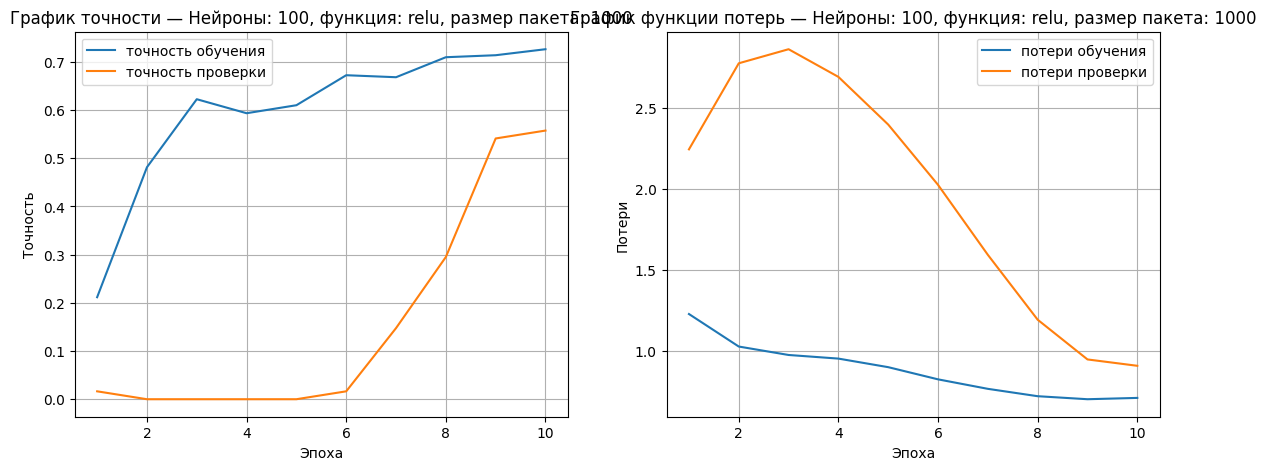


Модель: нейроны = 100, функция = linear, размер пакета = 10
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4855 - loss: 1.4414 - val_accuracy: 0.0328 - val_loss: 2.3972
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6100 - loss: 0.8740 - val_accuracy: 0.6066 - val_loss: 1.1490
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7054 - loss: 0.6595 - val_accuracy: 0.2787 - val_loss: 1.9123
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7137 - loss: 0.6592 - val_accuracy: 0.7049 - val_loss: 0.9649
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7925 - loss: 0.5609 - val_accuracy: 0.5410 - val_loss: 1.3018
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7801 - loss: 0.5358 - val_accuracy: 0.4426 - val_loss: 1.3912
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8216 - loss: 0.4860 - val_accuracy: 0.7869 - val_loss: 0.8089
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accu

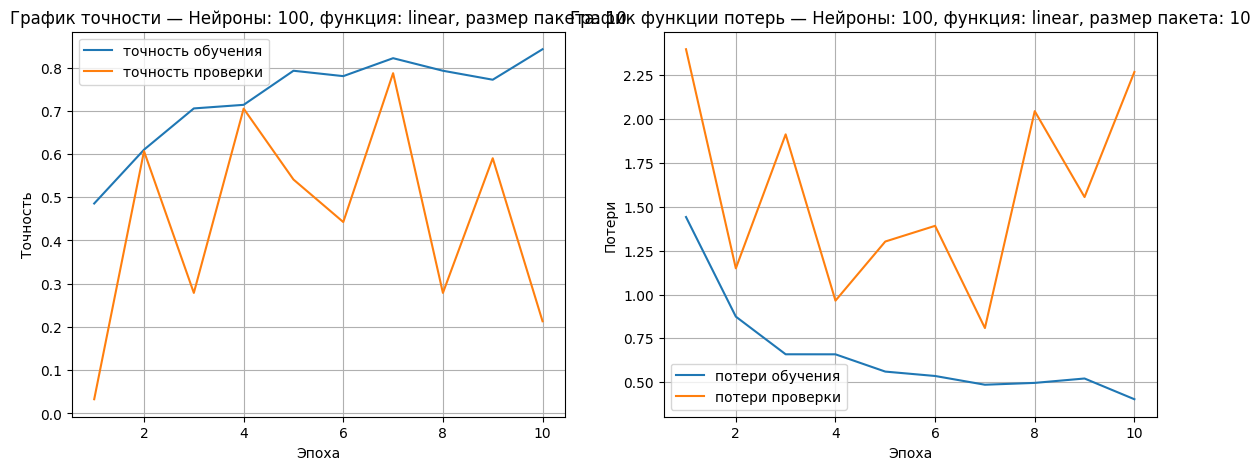


Модель: нейроны = 100, функция = linear, размер пакета = 100
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.3568 - loss: 1.7122 - val_accuracy: 0.6721 - val_loss: 0.7281
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4564 - loss: 1.2702 - val_accuracy: 0.0000e+00 - val_loss: 1.8984
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4938 - loss: 0.9911 - val_accuracy: 0.3115 - val_loss: 1.3071
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4523 - loss: 1.0813 - val_accuracy: 0.6066 - val_loss: 0.8522
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6432 - loss: 0.8432 - val_accuracy: 0.0820 - val_loss: 1.5087
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6141 - loss: 0.8707 - val_accuracy: 0.3443 - val_loss: 1.0812
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6722 - loss: 0.7743 - val_accuracy: 0.4754 - val_loss: 1.0486
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accurac

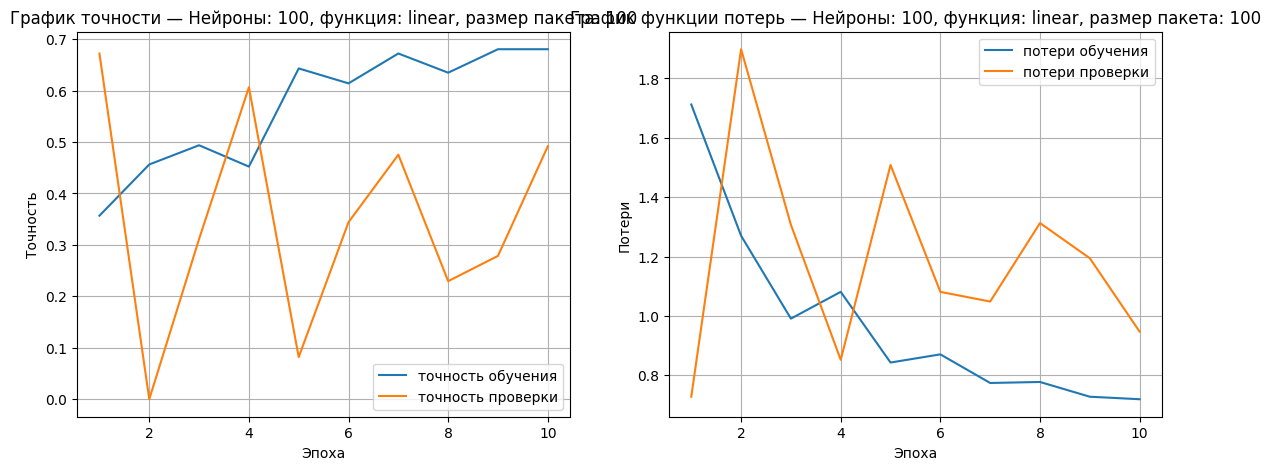


Модель: нейроны = 100, функция = linear, размер пакета = 1000
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2490 - loss: 2.1816 - val_accuracy: 0.0820 - val_loss: 1.8261
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4357 - loss: 1.2780 - val_accuracy: 0.0000e+00 - val_loss: 3.6816
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4440 - loss: 1.4312 - val_accuracy: 0.0000e+00 - val_loss: 4.1162
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5104 - loss: 1.2226 - val_accuracy: 0.0000e+00 - val_loss: 3.8880
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5228 - loss: 1.1328 - val_accuracy: 0.0000e+00 - val_loss: 3.0772
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4689 - loss: 1.0561 - val_accuracy: 0.0492 - val_loss: 1.9601
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5768 - loss: 0.8369 - val_accuracy: 0.3770 - val_loss: 1.1033
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124

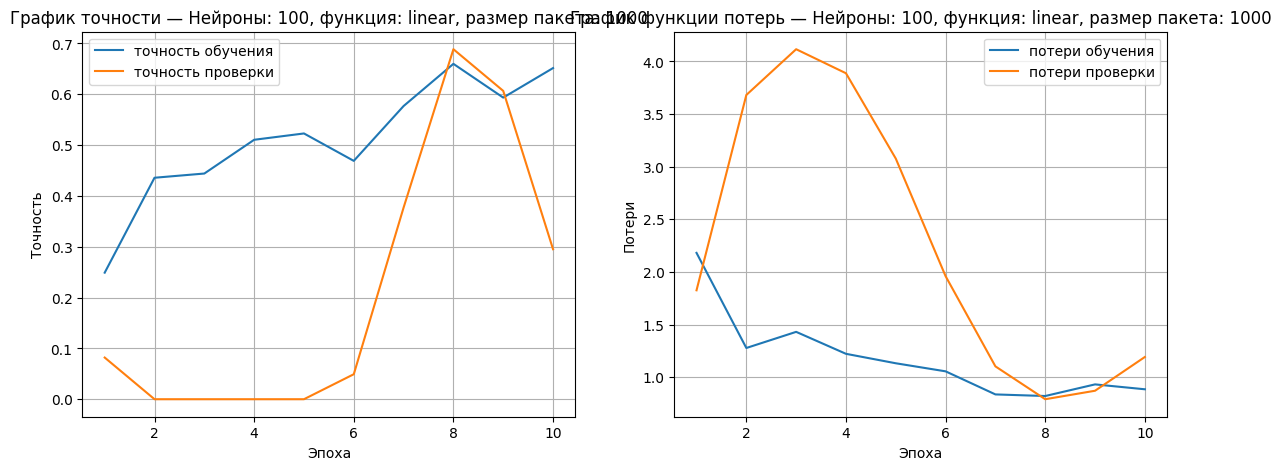


Модель: нейроны = 5000, функция = relu, размер пакета = 10
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4979 - loss: 2.0450 - val_accuracy: 0.5410 - val_loss: 0.7879
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6473 - loss: 0.7289 - val_accuracy: 0.4262 - val_loss: 1.3049
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7303 - loss: 0.5944 - val_accuracy: 0.7541 - val_loss: 0.7139
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8133 - loss: 0.5181 - val_accuracy: 0.2131 - val_loss: 2.0335
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8631 - loss: 0.3981 - val_accuracy: 0.3279 - val_loss: 1.7534
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8714 - loss: 0.3197 - val_accuracy: 0.6885 - val_loss: 1.0262
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9129 - loss: 0.2694 - val_accuracy: 0.5246 - val_loss: 1.4241
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step 

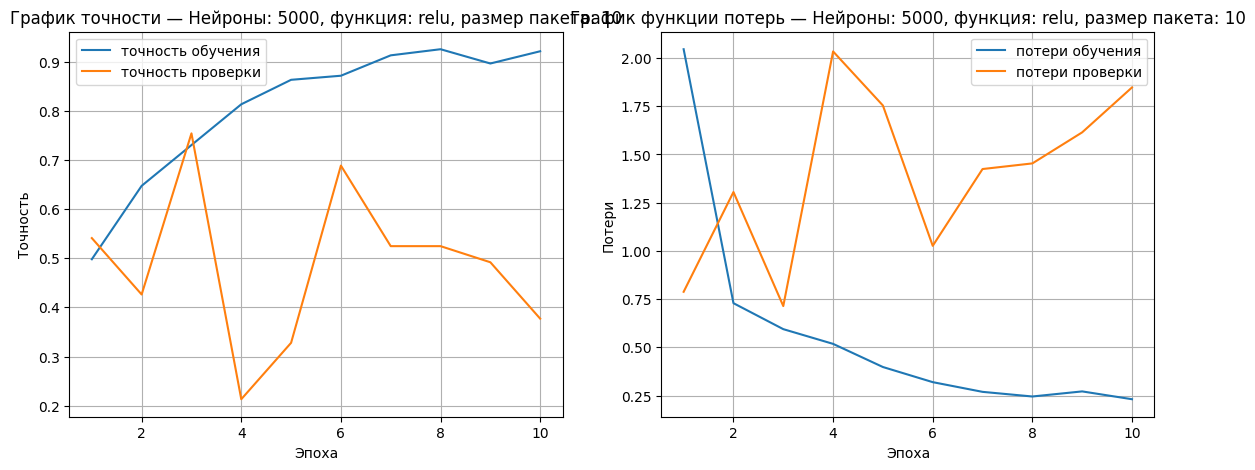


Модель: нейроны = 5000, функция = relu, размер пакета = 100
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.4066 - loss: 2.8807 - val_accuracy: 0.1639 - val_loss: 2.3740
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4772 - loss: 2.0269 - val_accuracy: 0.0000e+00 - val_loss: 3.3232
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6058 - loss: 1.1293 - val_accuracy: 0.9344 - val_loss: 0.2281
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6141 - loss: 0.8646 - val_accuracy: 0.0328 - val_loss: 2.5753
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6598 - loss: 0.8178 - val_accuracy: 0.0000e+00 - val_loss: 3.0319
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7012 - loss: 0.6803 - val_accuracy: 0.8197 - val_loss: 0.6778
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7967 - loss: 0.5960 - val_accuracy: 0.7049 - val_loss: 0.8531
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accu

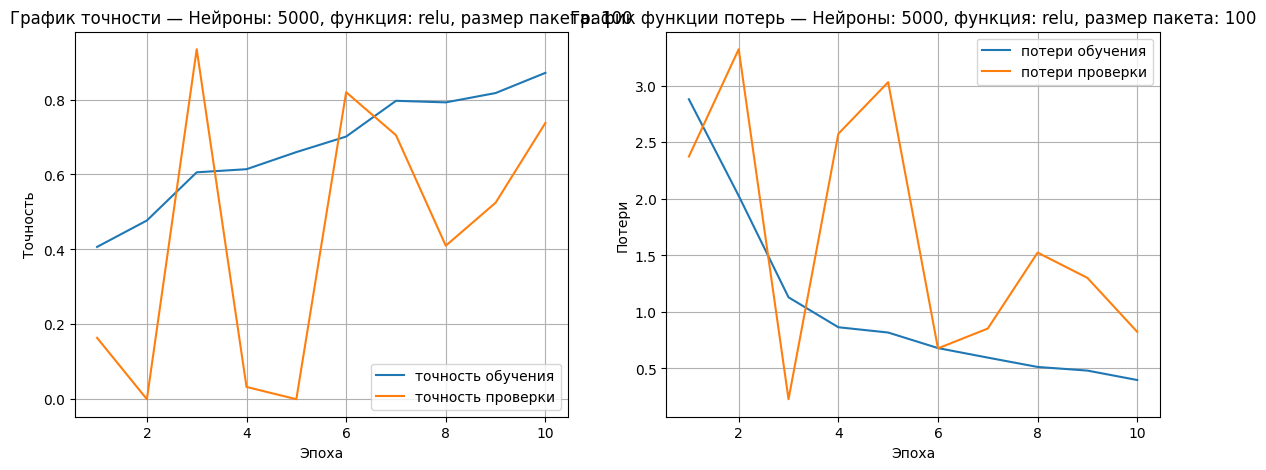


Модель: нейроны = 5000, функция = relu, размер пакета = 1000
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1743 - loss: 1.1698 - val_accuracy: 0.0000e+00 - val_loss: 14.1084
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.4647 - loss: 3.1910 - val_accuracy: 0.0000e+00 - val_loss: 17.0042
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.4149 - loss: 5.9464 - val_accuracy: 0.0000e+00 - val_loss: 12.2282
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.4149 - loss: 3.0812 - val_accuracy: 0.0000e+00 - val_loss: 10.2917
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5228 - loss: 2.5497 - val_accuracy: 0.0000e+00 - val_loss: 7.8845
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4232 - loss: 2.7676 - val_accuracy: 0.0000e+00 - val_loss: 4.4033
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.4772 - loss: 1.9187 - val_accuracy: 0.0984 - val_loss: 1.0624
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━

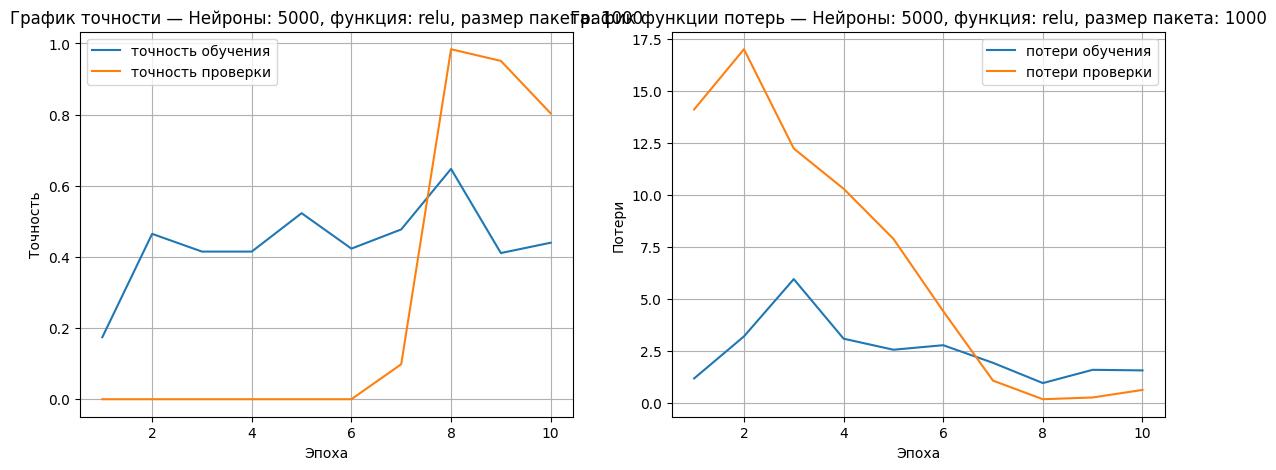


Модель: нейроны = 5000, функция = linear, размер пакета = 10
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4730 - loss: 5.1106 - val_accuracy: 0.6885 - val_loss: 1.1274
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6141 - loss: 1.2776 - val_accuracy: 0.6557 - val_loss: 1.3980
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6432 - loss: 0.9024 - val_accuracy: 0.8197 - val_loss: 0.8757
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7842 - loss: 0.5398 - val_accuracy: 0.5246 - val_loss: 1.4641
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7676 - loss: 0.5555 - val_accuracy: 0.2951 - val_loss: 2.2436
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7344 - loss: 0.5786 - val_accuracy: 0.2459 - val_loss: 2.4735
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7386 - loss: 0.6277 - val_accuracy: 0.8361 - val_loss: 0.5510
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/ste

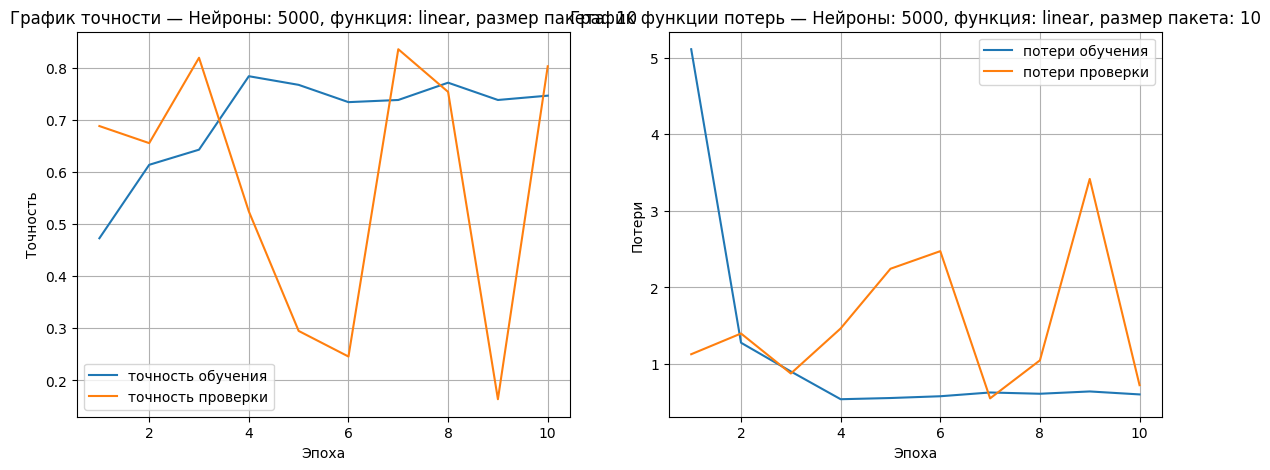


Модель: нейроны = 5000, функция = linear, размер пакета = 100
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.4274 - loss: 6.3287 - val_accuracy: 0.0000e+00 - val_loss: 27.8820
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.4191 - loss: 10.0026 - val_accuracy: 0.9836 - val_loss: 0.0698
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.3610 - loss: 5.0589 - val_accuracy: 0.0656 - val_loss: 2.4649
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.4689 - loss: 4.9117 - val_accuracy: 0.8197 - val_loss: 0.5160
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5892 - loss: 1.5538 - val_accuracy: 0.0000e+00 - val_loss: 7.7678
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4398 - loss: 3.0139 - val_accuracy: 0.0000e+00 - val_loss: 9.3547
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6473 - loss: 1.8869 - val_accuracy: 0.4918 - val_loss: 1.4571
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11

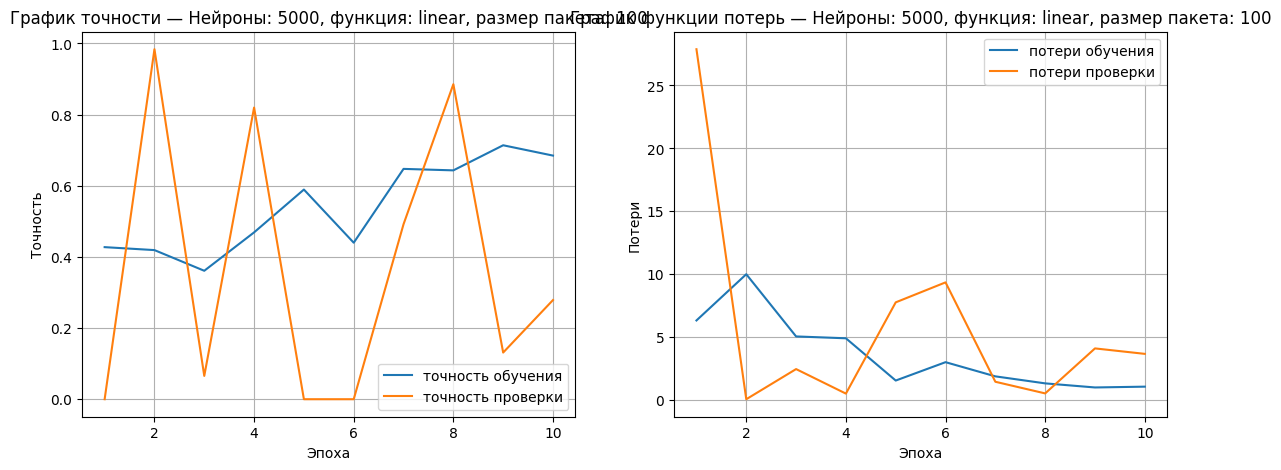


Модель: нейроны = 5000, функция = linear, размер пакета = 1000
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4232 - loss: 1.1073 - val_accuracy: 0.0000e+00 - val_loss: 29.4586
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.4149 - loss: 16.9075 - val_accuracy: 0.0000e+00 - val_loss: 18.3985
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.4149 - loss: 5.1104 - val_accuracy: 0.0000e+00 - val_loss: 23.8198
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.4232 - loss: 10.8188 - val_accuracy: 0.0000e+00 - val_loss: 16.9581
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.4232 - loss: 11.7882 - val_accuracy: 0.0000e+00 - val_loss: 3.8286
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4274 - loss: 8.2658 - val_accuracy: 1.0000 - val_loss: 2.1175e-05
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.1618 - loss: 13.6727 - val_accuracy: 1.0000 - val_loss: 5.1394e-05
Epoch 8/10
1/1 ━━━━━━

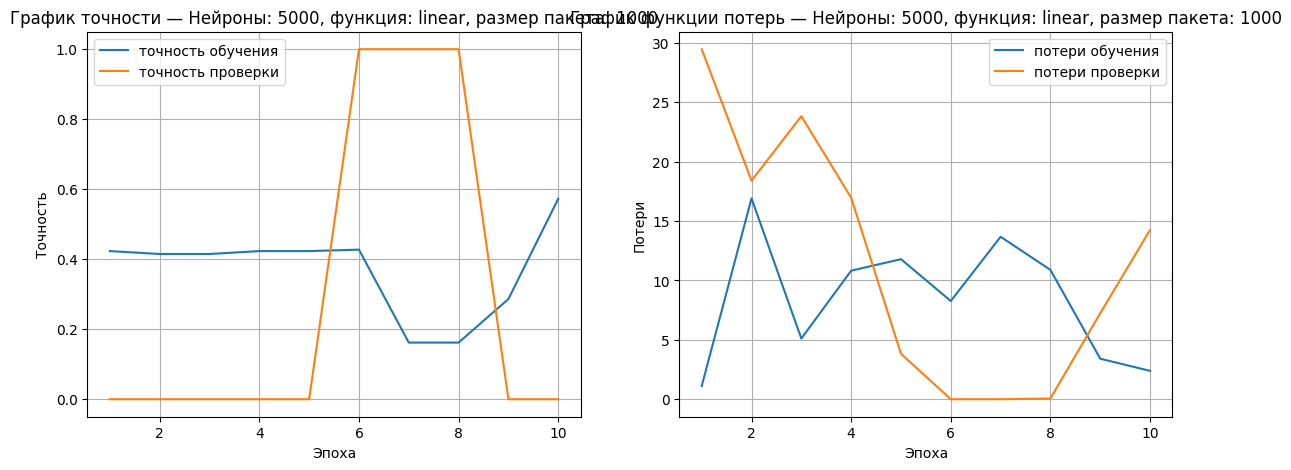

,Нейроны,Активация,Размер пакета,Ошибка,Точность
0,10,relu,10,0.794397,0.586093
1,10,relu,100,0.848184,0.635762
2,10,relu,1000,1.029358,0.466887
3,10,linear,10,0.662943,0.741722
4,10,linear,100,0.909053,0.559603
5,10,linear,1000,1.195255,0.450331
6,100,relu,10,0.597936,0.774834
7,100,relu,100,0.552929,0.801324
8,100,relu,1000,0.740732,0.711921
9,100,linear,10,0.928157,0.619205


In [43]:
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

# Список результатов
results = []

# Функция создания модели
def create_model(neurons, activation):
    model = Sequential()

    # Вход: изображение 20x20x1
    model.add(Input(shape=(20, 20, 1)))

    # Превращаем изображение в один длинный вектор
    model.add(Flatten())

    # Основной слой
    model.add(Dense(neurons, activation=activation))

    # Выходной слой на 3 класса
    model.add(Dense(3, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Функция построения графиков
def plot_history(history, neurons, activation, batch_size):
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(14, 5))

    # График точности
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], label='точность обучения')

    if 'val_accuracy' in history.history:
        plt.plot(epochs, history.history['val_accuracy'], label='точность проверки')

    plt.title(f'График точности — Нейроны: {neurons}, функция: {activation}, размер пакета: {batch_size}')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()
    plt.grid(True)

    # График потерь
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='потери обучения')

    if 'val_loss' in history.history:
        plt.plot(epochs, history.history['val_loss'], label='потери проверки')

    plt.title(f'График функции потерь — Нейроны: {neurons}, функция: {activation}, размер пакета: {batch_size}')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()
    plt.grid(True)

    plt.show()


# Настройки для всех моделей
neurons_list = [10, 100, 5000]
activation_list = ['relu', 'linear']
batch_size_list = [10, 100, 1000]

# Запуск всех вариантов
for neurons in neurons_list:
    for activation in activation_list:
        for batch_size in batch_size_list:

            print(f'\nМодель: нейроны = {neurons}, функция = {activation}, размер пакета = {batch_size}')

            model = create_model(neurons, activation)

            history = model.fit(
                x_train,
                y_train,
                epochs=10,
                batch_size=batch_size,
                validation_split=0.2
            )

            loss, accuracy = model.evaluate(x_train, y_train)

            results.append([neurons, activation, batch_size, loss, accuracy])

            plot_history(history, neurons, activation, batch_size)


# Итоговая таблица
df = pd.DataFrame(
    results,
    columns=["Нейроны", "Активация", "Размер пакета", "Ошибка", "Точность"]
)

display(df)